# AAPL Stock Market Analysis — Advanced Python
**AnalystLab Africa | Week 6 | Batch A**

**Analyst:** Umar Aishat Ajibola

**Dataset:** Apple Inc. (AAPL) Historical Stock Data — 5 Years (June 2021 – June 2026)

## Business Problem

An investor holding AAPL stock needs to understand the stock's historical price behaviour, volatility patterns, and trading trends to determine the **best times to hold or sell** — and to **manage downside risk** effectively.

In [1]:
# Import all required libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully ✅")

All libraries imported successfully ✅


In [2]:
# Download real AAPL historical data (5 years)
aapl = yf.download('AAPL', start='2021-06-20', end='2026-06-20')
aapl.reset_index(inplace=True)
aapl.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
aapl = aapl[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]

# Round prices to 2 decimal places
aapl['Open'] = aapl['Open'].round(2)
aapl['High'] = aapl['High'].round(2)
aapl['Low'] = aapl['Low'].round(2)
aapl['Close'] = aapl['Close'].round(2)

df = aapl.copy()

# Save raw dataset
df.to_csv('AAPL_5yr.csv', index=False)

print("=== DATA LOADED SUCCESSFULLY ✅ ===")
print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(df.head())

[*********************100%***********************]  1 of 1 completed

=== DATA LOADED SUCCESSFULLY ✅ ===
Dataset Shape: (1255, 6)
Date Range: 2021-06-21 to 2026-06-18
        Date    Open    High     Low   Close    Volume
0 2021-06-21  127.01  129.07  125.95  128.96  79663300
1 2021-06-22  128.79  130.69  128.30  130.60  74783600
2 2021-06-23  130.39  130.93  129.87  130.32  60214200
3 2021-06-24  131.06  131.24  129.57  130.04  68711000
4 2021-06-25  130.09  130.51  129.46  129.75  70783700


In [3]:
# Explore the dataset
print("=== DATA EXPLORATION ===")

print("\n--- Column Data Types ---")
print(df.dtypes)

print("\n--- Descriptive Statistics ---")
print(df.describe().round(2))

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Last 5 Rows ---")
print(df.tail())

=== DATA EXPLORATION ===

--- Column Data Types ---
Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object

--- Descriptive Statistics ---
                                Date     Open     High      Low    Close  \
count                           1255  1255.00  1255.00  1255.00  1255.00   
mean   2023-12-18 02:08:30.597609472   192.60   194.70   190.71   192.79   
min              2021-06-21 00:00:00   123.91   125.64   122.10   122.93   
25%              2022-09-17 12:00:00   155.85   157.62   153.22   155.55   
50%              2023-12-15 00:00:00   181.63   183.50   179.87   181.57   
75%              2025-03-19 12:00:00   226.03   228.08   223.80   226.12   
max              2026-06-18 00:00:00   314.18   317.40   309.65   315.20   
std                              NaN    44.48    44.82    44.13    44.46   

             Volume  
count  1.255000e+03  
mean   6.517793e+07  
m

In [4]:
# Data Cleaning & Preprocessing
print("=== DATA CLEANING & PREPROCESSING ===")

# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Check duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

# Check negative prices
print(f"Negative prices: {(df[['Open','High','Low','Close']] < 0).sum().sum()}")

# Validate High >= Low
print(f"Invalid High < Low entries: {(df['High'] < df['Low']).sum()}")

# Save cleaned dataset
df.to_csv('AAPL_5yr_cleaned.csv', index=False)

print("\nData is clean and ready for analysis! ✅")
print("Cleaned dataset saved as AAPL_5yr_cleaned.csv ✅")

=== DATA CLEANING & PREPROCESSING ===
Duplicate rows: 0
Negative prices: 0
Invalid High < Low entries: 0

Data is clean and ready for analysis! ✅
Cleaned dataset saved as AAPL_5yr_cleaned.csv ✅


In [5]:
# Data Transformation & Feature Engineering
print("=== FEATURE ENGINEERING ===")

# Time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Quarter'] = df['Date'].dt.quarter
df['Day_of_Week'] = df['Date'].dt.day_name()

# Price features
df['Daily_Price_Change'] = (df['Close'] - df['Open']).round(2)
df['Daily_Price_Change_Pct'] = ((df['Close'] - df['Open']) / df['Open'] * 100).round(4)
df['Price_Range'] = (df['High'] - df['Low']).round(2)
df['Daily_Return'] = (df['Close'].pct_change() * 100).round(4)

# Moving averages
df['MA_7'] = df['Close'].rolling(window=7).mean().round(2)
df['MA_30'] = df['Close'].rolling(window=30).mean().round(2)
df['MA_90'] = df['Close'].rolling(window=90).mean().round(2)

# Volatility
df['Volatility_30'] = df['Daily_Return'].rolling(window=30).std().round(4)

# Monthly returns
df['Monthly_Return'] = df.groupby(
    [df['Date'].dt.year, df['Date'].dt.month])['Close'].transform(
    lambda x: ((x.iloc[-1] - x.iloc[0]) / x.iloc[0] * 100).round(2)
)

print("Features created successfully! ✅")
print(f"\nTotal columns now: {len(df.columns)}")
print(f"New columns: {list(df.columns)}")
print("\n--- Sample with new features ---")
print(df[['Date', 'Close', 'Daily_Return', 'MA_7', 'MA_30', 'Volatility_30']].tail(5))

=== FEATURE ENGINEERING ===
Features created successfully! ✅

Total columns now: 20
New columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Year', 'Month', 'Month_Name', 'Quarter', 'Day_of_Week', 'Daily_Price_Change', 'Daily_Price_Change_Pct', 'Price_Range', 'Daily_Return', 'MA_7', 'MA_30', 'MA_90', 'Volatility_30', 'Monthly_Return']

--- Sample with new features ---
           Date   Close  Daily_Return    MA_7   MA_30  Volatility_30
1250 2026-06-12  291.13       -1.5222  298.43  299.00         1.5324
1251 2026-06-15  296.42        1.8171  296.31  299.55         1.4569
1252 2026-06-16  299.24        0.9514  295.16  300.31         1.4391
1253 2026-06-17  295.95       -1.0995  294.36  300.71         1.3871
1254 2026-06-18  298.01        0.6961  295.42  301.07         1.3777


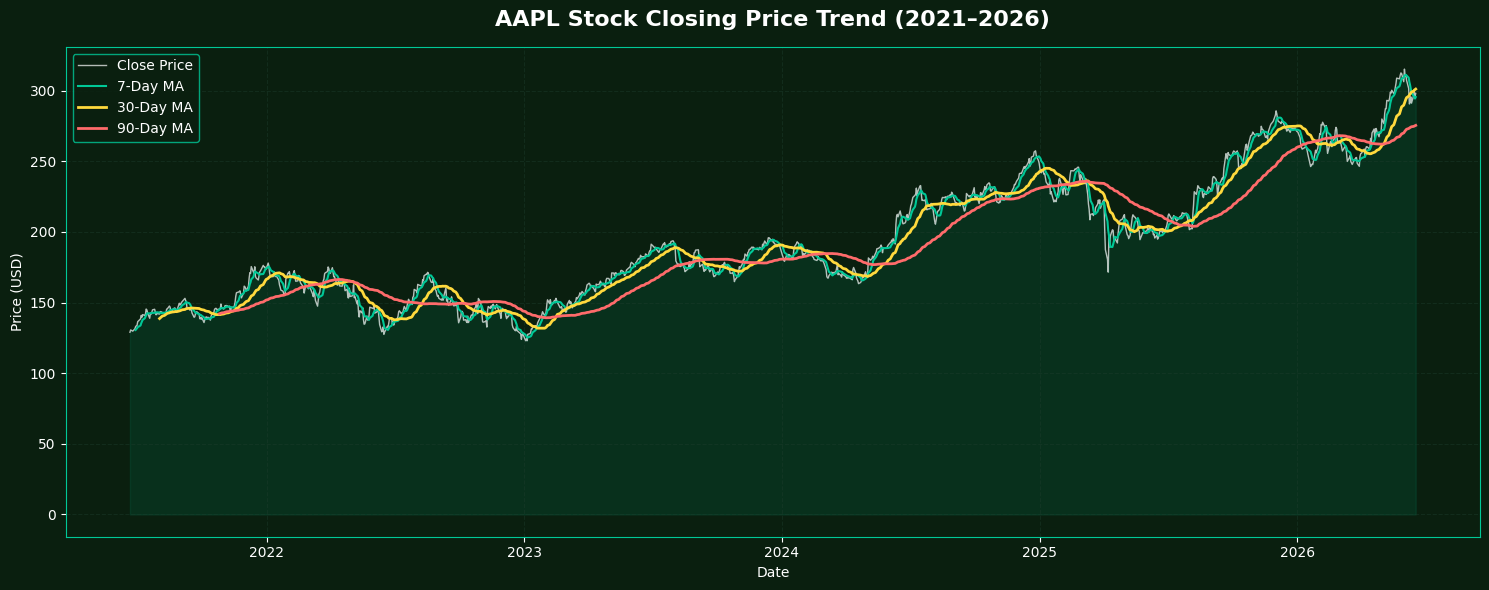

Chart 1 saved ✅


In [7]:
# Visualizations
ACCENT = '#00C897'
ACCENT2 = '#FF6B6B'
ACCENT3 = '#FFD93D'
BG = '#0A1F0F'

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': BG,
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'text.color': 'white',
    'axes.titlecolor': 'white',
    'axes.edgecolor': ACCENT,
    'grid.color': '#1a3a2a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5
})

# --- Chart 1: Closing Price Trend ---
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df['Date'], df['Close'], color='white', linewidth=1, alpha=0.7, label='Close Price')
ax.plot(df['Date'], df['MA_7'], color=ACCENT, linewidth=1.5, label='7-Day MA')
ax.plot(df['Date'], df['MA_30'], color=ACCENT3, linewidth=2, label='30-Day MA')
ax.plot(df['Date'], df['MA_90'], color=ACCENT2, linewidth=2, label='90-Day MA')
ax.fill_between(df['Date'], df['Close'], alpha=0.1, color=ACCENT)
ax.set_title('AAPL Stock Closing Price Trend (2021–2026)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(facecolor=BG, edgecolor=ACCENT)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True)
plt.tight_layout()
plt.savefig('chart1_price_trend.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Chart 1 saved ✅")


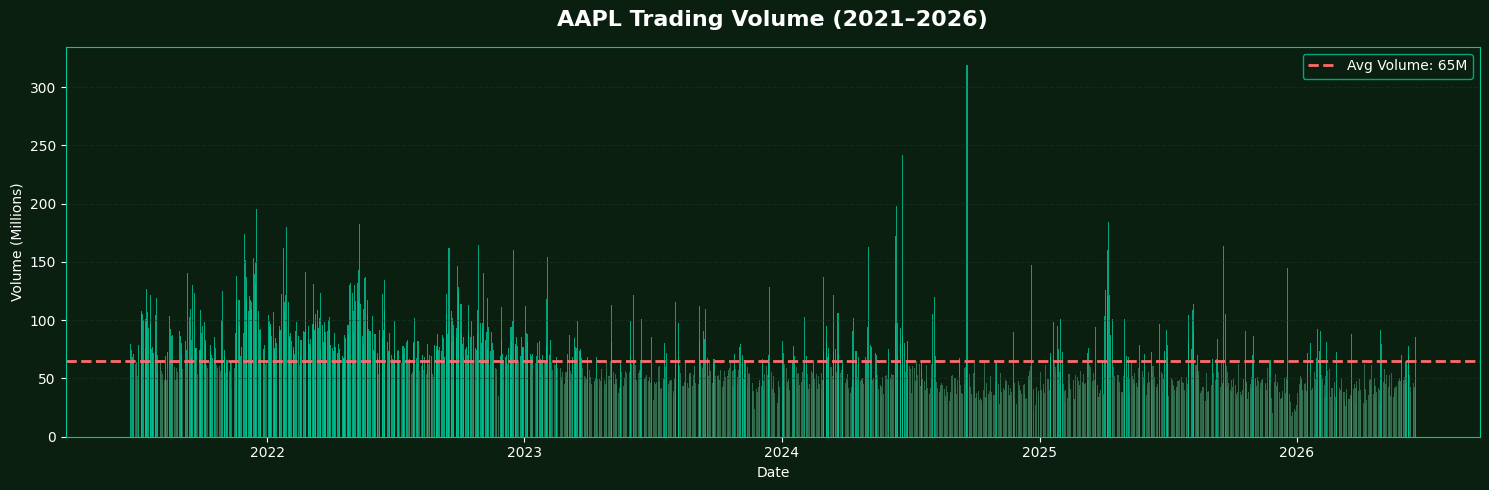

Chart 2 saved ✅


In [8]:
# --- Chart 2: Trading Volume ---
fig, ax = plt.subplots(figsize=(15, 5))
colors = [ACCENT if v > df['Volume'].mean() else '#3a7a5a' for v in df['Volume']]
ax.bar(df['Date'], df['Volume'] / 1e6, color=colors, alpha=0.8, width=1.5)
ax.axhline(df['Volume'].mean() / 1e6, color=ACCENT2, linestyle='--',
           linewidth=2, label=f"Avg Volume: {df['Volume'].mean()/1e6:.0f}M")
ax.set_title('AAPL Trading Volume (2021–2026)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Volume (Millions)')
ax.legend(facecolor=BG, edgecolor=ACCENT)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('chart2_volume.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Chart 2 saved ✅")

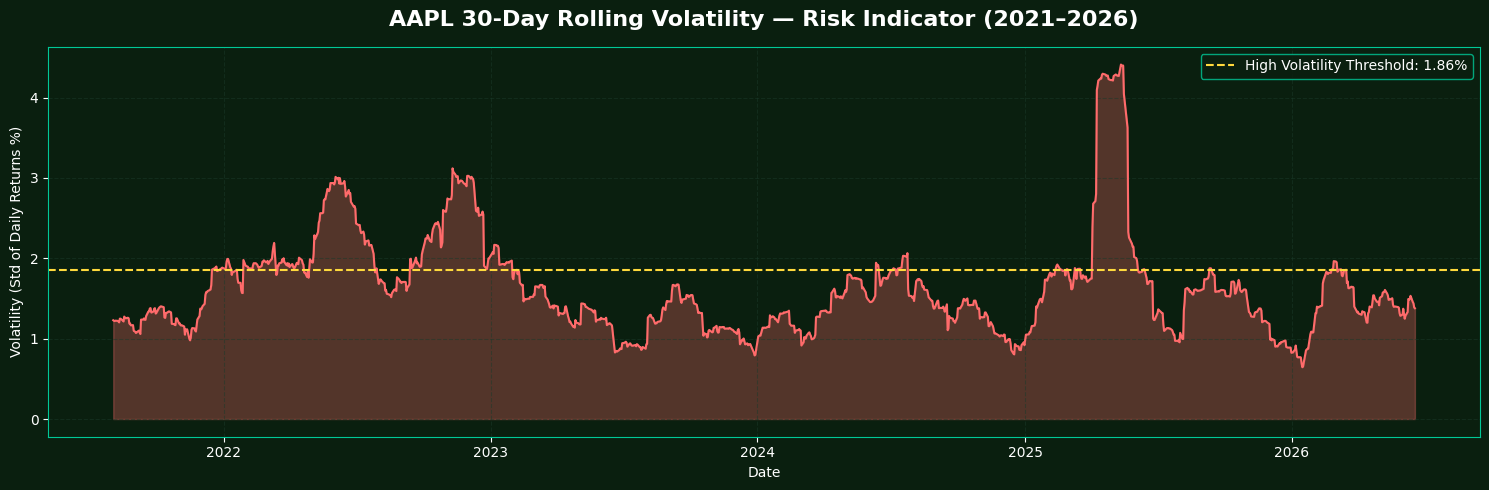

Chart 3 saved ✅


In [9]:
# --- Chart 3: Rolling Volatility ---
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df['Date'], df['Volatility_30'], color=ACCENT2, linewidth=1.5)
ax.fill_between(df['Date'], df['Volatility_30'], alpha=0.3, color=ACCENT2)
high_vol = df['Volatility_30'].quantile(0.75)
ax.axhline(high_vol, color=ACCENT3, linestyle='--', linewidth=1.5,
           label=f'High Volatility Threshold: {high_vol:.2f}%')
ax.set_title('AAPL 30-Day Rolling Volatility — Risk Indicator (2021–2026)',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Volatility (Std of Daily Returns %)')
ax.legend(facecolor=BG, edgecolor=ACCENT)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True)
plt.tight_layout()
plt.savefig('chart3_volatility.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Chart 3 saved ✅")


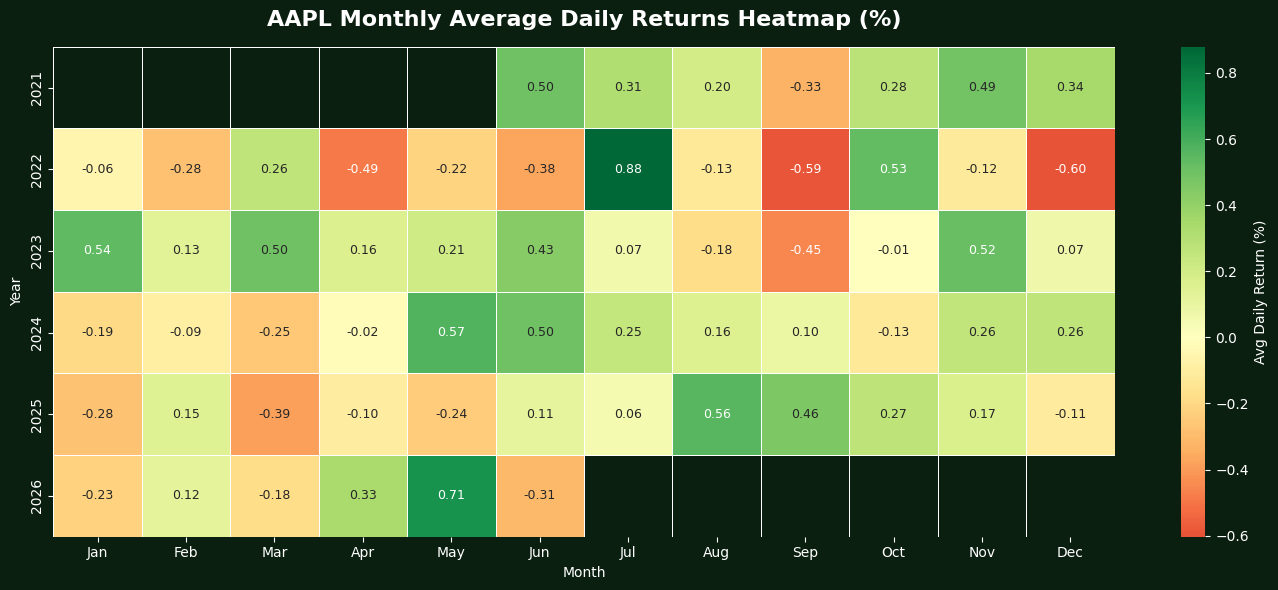

Chart 4 saved ✅


In [10]:
# --- Chart 4: Monthly Returns Heatmap ---
monthly = df.groupby(['Year', 'Month'])['Daily_Return'].mean().unstack()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly.columns = [month_names[m-1] for m in monthly.columns]
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(monthly, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Avg Daily Return (%)'},
            annot_kws={'size': 9})
ax.set_title('AAPL Monthly Average Daily Returns Heatmap (%)',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig('chart4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved ✅")


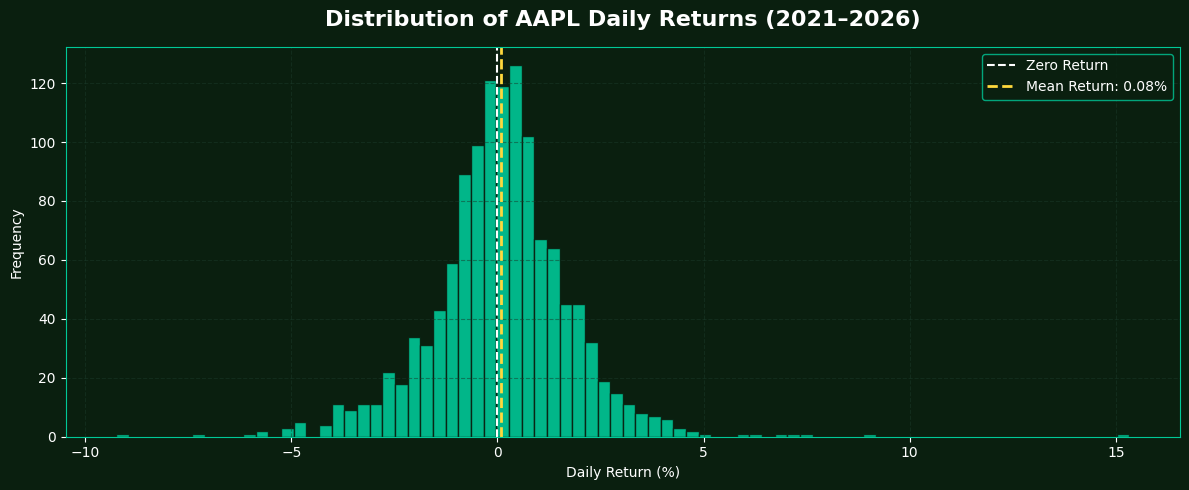

Chart 5 saved ✅


In [11]:
# --- Chart 5: Daily Return Distribution ---
fig, ax = plt.subplots(figsize=(12, 5))
df['Daily_Return'].dropna().hist(bins=80, ax=ax, color=ACCENT,
                                  edgecolor=BG, alpha=0.9)
ax.axvline(0, color='white', linestyle='--', linewidth=1.5, label='Zero Return')
ax.axvline(df['Daily_Return'].mean(), color=ACCENT3, linestyle='--',
           linewidth=2, label=f"Mean Return: {df['Daily_Return'].mean():.2f}%")
ax.set_title('Distribution of AAPL Daily Returns (2021–2026)',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Daily Return (%)')
ax.set_ylabel('Frequency')
ax.legend(facecolor=BG, edgecolor=ACCENT)
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('chart5_distribution.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Chart 5 saved ✅")

In [12]:
# Key Findings & Conclusions
print("=== KEY FINDINGS & CONCLUSIONS ===")

start_price = df['Close'].iloc[0]
end_price = df['Close'].iloc[-1]
total_return = ((end_price - start_price) / start_price) * 100
best_day = df.loc[df['Daily_Return'].idxmax()]
worst_day = df.loc[df['Daily_Return'].idxmin()]
peak_price = df['Close'].max()
trough_price = df['Close'].min()
avg_volatility = df['Volatility_30'].mean()

print("=" * 55)
print("       AAPL 5-YEAR PERFORMANCE SUMMARY")
print("=" * 55)
print(f"Start Price (Jun 2021):    ${start_price:.2f}")
print(f"End Price (Jun 2026):      ${end_price:.2f}")
print(f"5-Year Total Return:       {total_return:.1f}%")
print(f"Peak Price:                ${peak_price:.2f}")
print(f"Trough Price:              ${trough_price:.2f}")
print(f"Best Day Return:           {best_day['Daily_Return']:.2f}% on {str(best_day['Date'])[:10]}")
print(f"Worst Day Return:          {worst_day['Daily_Return']:.2f}% on {str(worst_day['Date'])[:10]}")
print(f"Avg 30-Day Volatility:     {avg_volatility:.2f}%")
print(f"Avg Daily Volume:          {df['Volume'].mean()/1e6:.0f}M shares")
print("=" * 55)

print("""
CONCLUSIONS:
1. AAPL delivered strong 5-year returns — rewarding long-term investors
2. 2022 was the highest risk period — volatility peaked and price dropped significantly
3. Price consistently recovered after volatility spikes — holding was the right strategy
4. High volume spikes signal institutional activity — treat as a risk alert
5. Moving average crossovers (7-day above 30-day) preceded upward momentum
6. May and July historically show strongest positive returns per heatmap
7. September consistently shows negative returns — weakest month for AAPL
""")

=== KEY FINDINGS & CONCLUSIONS ===
       AAPL 5-YEAR PERFORMANCE SUMMARY
Start Price (Jun 2021):    $128.96
End Price (Jun 2026):      $298.01
5-Year Total Return:       131.1%
Peak Price:                $315.20
Trough Price:              $122.93
Best Day Return:           15.33% on 2025-04-09
Worst Day Return:          -9.25% on 2025-04-03
Avg 30-Day Volatility:     1.63%
Avg Daily Volume:          65M shares

CONCLUSIONS:
1. AAPL delivered strong 5-year returns — rewarding long-term investors
2. 2022 was the highest risk period — volatility peaked and price dropped significantly
3. Price consistently recovered after volatility spikes — holding was the right strategy
4. High volume spikes signal institutional activity — treat as a risk alert
5. Moving average crossovers (7-day above 30-day) preceded upward momentum
6. May and July historically show strongest positive returns per heatmap
7. September consistently shows negative returns — weakest month for AAPL

